# Notebook to calculate the change in shape plots for the canonical model: Figures 5 and 6
## Preamble
### Load in required modules 

In [1]:
#SJL 6/2020
#Script to plot the change in surface length for planets in the canonical model


###########################################################
###########################################################
###########################################################
import numpy as np
import scipy as sp
import sys
import os
import struct
from scipy import constants as const

#package to use wildcards 
import fnmatch

from scipy.interpolate import LinearNDInterpolator
from scipy.interpolate import griddata

#plotting packages
import matplotlib as mpl
#mpl.use('PDF')
import matplotlib.pyplot as plt
import pylab
import matplotlib.cm as cm
from matplotlib import gridspec

cwd = os.getcwd()
print(cwd)
if sys.platform== 'darwin':
    sys.path.insert(0, cwd+'/Support_scipts')
    print(cwd+'/Support_scripts')
elif (sys.platform== 'win32') | (sys.platform== 'win64'):
    sys.path.insert(0,cwd+"\\Support_scipts")


#HERCULES_structures
from HERCULES_structures import *
from surface_size_calc import *
from HERCULES_random_planet_database_structure_1D import *

#functions for calculating non-evenly spaced numerical differentials
from gradients import *

#import colormaps
import colormaps as cmaps
import matplotlib.cm as cm

import svglib.svglib as svglib
svglib.register_font('helvetica', './Helvetica.ttc')


/Users/vq21447/Documents/Lock_2026_SI
/Users/vq21447/Documents/Lock_2026_SI/Support_scripts
CHECK THE LOCATION OF ODYSSEY BACKUP
CHECK THE LOCATION OF ODYSSEY BACKUP


('helvetica', True)

### Define constants to normalize axes etc.

In [2]:
########################################################################################
########################################################################################
########################################################################################
#CONSTANTS
MEarth=5.972E24
LEM=3.5E34
REarth=6.371E6
MMoon=7.34767309E22

aMoon=0.3844E9
aCassini=30*REarth
aRoche=2.9*REarth

#for HERCULES
MEarth_H=5.9879648E24
LEM_H=3.53E34

### Set parameters and select bodies to plot

In [3]:
########################################################################################
########################################################################################
########################################################################################
#PARAMS
Hdir='Earth_correct_params_S3.20c'
Hname='Earth_correct_params_S3.20c'

#flag as to whether to run in plotting mode or whether to redo calculations
flag_calc=0

#number of contor lines
Ncont=20


## Main script¶
### Either calculate the shape or read in the pre-calculated data

In [4]:
########################################################
########################################################
#either do the calcualtions or load the data
print('begin')


if flag_calc==1:
    

    ########################################################################################
    #read in the database
    
    Hdatabase=HERCULES_random_planet_database_1D()
    Hdatabase.make_array(Hdir,Hname)
    Hdatabase.initialize_interpolation([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1],\
                                       [0,0,[],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]], flag_extrap=1)
    
    #extract the latitudes for each Mu point
    Nmu=Hdatabase.parr[0].Nmu
    lat=np.arccos(Hdatabase.parr[0].layers[0].mu)*180/np.pi

    #calculate the pattern and rate of deformation for an example tidal evolution for contout plot


    #constants
    k2Q=0.3/100.0
    a0=2.9*REarth
    Ltot=LEM
    
    Nt=100
    
    t=np.linspace(0.1,20,Nt)*1E6*const.year
    
    #calculate the orbit
    kappa=3.0*k2Q*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon))
    a=((13.0/2.0)*(kappa*t+(2.0/13.0)*(a0**(13.0/2.0))))**(2.0/13.0)
    L=Ltot-(MMoon)*np.sqrt(const.G*a*(MEarth+MMoon))
    dLdt=-0.5*MMoon/np.sqrt(const.G*a*(MEarth+MMoon))*const.G*(MEarth+MMoon)*kappa*(a**(-11.0/2.0))

    #run through and extract lengths and areas at each time point
    dl_lat=np.zeros((Nt,Nmu))
    dl_lon=np.zeros((Nt,Nmu))
    dA=np.zeros((Nt,Nmu))
    
    ddl_lat_dL=np.zeros((Nt,Nmu))
    ddl_lon_dL=np.zeros((Nt,Nmu))
    ddA_dL=np.zeros((Nt,Nmu))
    
    ddl_lat_dt=np.zeros((Nt,Nmu))
    ddl_lon_dt=np.zeros((Nt,Nmu))
    ddA_dt=np.zeros((Nt,Nmu))
    
    rsurf=np.zeros((Nt,Nmu))
    
    
    #now loop through and find the deformation rates
    for i in np.arange(Nt):
        print(i,'/',Nt)
         
        temp_data=Hdatabase.interp_database(L[i],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1],\
                                           [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)
    
        temp=np.asarray(temp_data[16])
    
        dl_lat[i,:]=temp[:,0]
        dl_lon[i,:]=temp[:,1]
        dA[i,:]=temp[:,2]
    
        ddl_lat_dL[i,:]=temp[:,3]
        ddl_lon_dL[i,:]=temp[:,4]
        ddA_dL[i,:]=temp[:,5]
    
        ddl_lat_dt[i,:]=temp[:,3]*dLdt[i]
        ddl_lon_dt[i,:]=temp[:,4]*dLdt[i]
        ddA_dt[i,:]=temp[:,5]*dLdt[i]
        
        rsurf[i,:]=np.asarray(temp_data[17])

    #activate if you want to reprint the run data
    if 1==0:
        np.savez('Data/Figure5and6', Nmu=Nmu, lat=lat, k2Q=k2Q, a0=a0, Ltot=Ltot, Nt=Nt, t=t, kappa=kappa, a=a, L=L, dLdt=dLdt,\
                 dl_lat=dl_lat, dl_lon=dl_lon, dA=dA, ddl_lat_dL=ddl_lat_dL, ddl_lon_dL=ddl_lon_dL,\
                 ddA_dL=ddA_dL, ddl_lat_dt=ddl_lat_dt, ddl_lon_dt=ddl_lon_dt, ddA_dt=ddA_dt, rsurf=rsurf)

else:

    temp=np.load("Data/Figure5and6.npz")
    Nmu=temp['Nmu']
    lat=temp['lat']
    k2Q=temp['k2Q']
    a0=temp['a0']
    Ltot=temp['Ltot']
    Nt=temp['Nt']
    t=temp['t']
    kappa=temp['kappa']
    a=temp['a']
    L=temp['L']
    dLdt=temp['dLdt']
    dl_lat=temp['dl_lat']
    dl_lon=temp['dl_lon']
    dA=temp['dA']
    ddl_lat_dL=temp['ddl_lat_dL']
    ddl_lon_dL=temp['ddl_lon_dL']
    ddA_dL=temp['ddA_dL']
    ddl_lat_dt=temp['ddl_lat_dt']
    ddl_lon_dt=temp['ddl_lon_dt']
    ddA_dt=temp['ddA_dt']
    rsurf=temp['rsurf']
    
    
    
    
    
print('end')


begin
end


### Calculate the grid of data to plot

In [5]:
print('begin cat')

#calculate the interpolation hulls
lat_grid=np.linspace(0, 90, Ncont*(Ncont+1))
t_grid=np.linspace(np.amin(t), np.amax(t),Ncont*(Ncont+1))/const.year/1E6

#make the controur grids
LLL, TTT = np.meshgrid(t_grid, lat_grid)

temp=np.ones(np.shape(ddl_lat_dt))
time_arr=temp*t[:, None]
lat_arr=temp*lat[None,:]

#interpolate onto grid
DLON=griddata(((time_arr.flatten()/const.year/1E6,90.0-lat_arr.flatten())),ddl_lon_dt.flatten()*const.year*np.pi/180.0,(LLL,TTT))#, method='linear')
DLAT=griddata(((time_arr.flatten()/const.year/1E6,90.0-lat_arr.flatten())),ddl_lat_dt.flatten()*const.year*np.pi/180.0,(LLL,TTT))#, method='linear')
AAA=griddata(((time_arr.flatten()/const.year/1E6,90.0-lat_arr.flatten())),ddA_dt.flatten()*const.year*(np.pi/180.0)**2,(LLL,TTT))#, method='linear')

print('end cat')


begin cat
end cat


### Calculate additional a and L points, to give a continuous curve

In [6]:
#Also run a set of calculations that go earlier in time for a and L

t_plot=np.logspace(-10,np.log10(20),100*Nt)*1E6*const.year

#run through and extract lengths and areas at each time point
kappa=3.0*k2Q*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon))
a_plot=((13.0/2.0)*(kappa*t_plot+(2.0/13.0)*(a0**(13.0/2.0))))**(2.0/13.0)
L_plot=Ltot-(MMoon)*np.sqrt(const.G*a_plot*(MEarth+MMoon))

### Construct Figure 6

begin lobster


/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_55212/913940380.py:58: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour10 = ax[0][2].contour(LLL, TTT, DLAT, linewidth=1.5, levels=[0.0], colors=['k'], linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_55212/913940380.py:61: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour20 = ax[0][3].contour(LLL, TTT, DLON, linewidth=1.5, levels=[0.0], colors=['k'],linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_55212/913940380.py:64: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour30 = ax[0][4].contour(LLL, TTT, AAA, linewidth=1.5, levels=[0], colors=['k'], linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_55212/913940380.py:92: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases la

38.755319018062806
end lobster


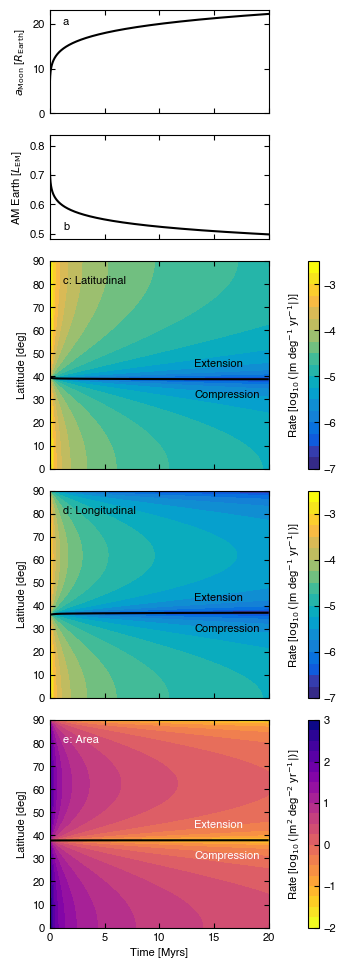

In [7]:
print('begin lobster')
#plot the contour plot for deformation as a function of latitude


#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('Figure6.pdf')
mpl.pyplot.close(fig)


#initialise the real figure
fig = plt.figure(figsize=(3.5,9.724))
gs = gridspec.GridSpec(5, 2,
                      width_ratios=[1,0.05],
                      height_ratios=[0.5,0.5,1,1,1])
ax=[[]]
ax[0].append(plt.subplot(gs[0]))
ax[0].append(plt.subplot(gs[2], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[4], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[6], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[8], sharex=ax[0][0]))

ax_col=[[]]
ax_col[0].append(plt.subplot(gs[5]))
ax_col[0].append(plt.subplot(gs[7]))
ax_col[0].append(plt.subplot(gs[9]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)


ax[0][0].plot(t_plot/const.year/1E6, a_plot/REarth, 'k-', linewidth=1.5)

ax[0][1].plot(t_plot/const.year/1E6, L_plot/LEM, 'k-', linewidth=1.5)

lat_contours=np.linspace(-7,-2.5,18+1)
lon_contours=np.linspace(-7,-2.5,18+1)
Acontours=np.linspace(-2,3,20+1)

lat_labels=np.asarray([-7,-6,-5,-4,-3])
lon_labels=np.asarray([-7,-6,-5,-4,-3])
Alabels=np.asarray([-2,-1,0,1,2,3])

contour1 = ax[0][2].contourf(LLL, TTT, np.log10(np.absolute(DLAT)), levels=lat_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lat_contours)-1)))
contour10 = ax[0][2].contour(LLL, TTT, DLAT, linewidth=1.5, levels=[0.0], colors=['k'], linestyles='solid')
#temp = ax[0][0].contour(LLL, TTT, DLAT, linewidth=1.5, levels=[-4,4], colors=['k'], linestyles='dashed')
contour2 = ax[0][3].contourf(LLL, TTT, np.log10(np.absolute(DLON)), levels=lon_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lon_contours)-1)))
contour20 = ax[0][3].contour(LLL, TTT, DLON, linewidth=1.5, levels=[0.0], colors=['k'],linestyles='solid')
#temp = ax[0][1].contour(LLL, TTT, DLON, linewidth=1.5, levels=[-4,4], colors=['k'], linestyles='dashed')
contour3 = ax[0][4].contourf(LLL, TTT, np.log10(np.absolute(AAA)), levels=Acontours, colors=cm.plasma(np.linspace(1, 0, np.size(Acontours)-1)))
contour30 = ax[0][4].contour(LLL, TTT, AAA, linewidth=1.5, levels=[0], colors=['k'], linestyles='solid')
#temp = ax[0][2].contour(LLL, TTT, AAA/1E6, linewidth=1.5, levels=[-10,10], colors=['k'], linestyles='dashed')

ax[0][0].set_ylabel(r"$a_\mathrm{Moon}$ [$R_\mathrm{Earth}$]")
ax[0][1].set_ylabel(r"AM Earth [$L_\mathrm{EM}$]")
ax[0][2].set_ylabel("Latitude [deg]")
ax[0][3].set_ylabel("Latitude [deg]")
ax[0][4].set_ylabel("Latitude [deg]")
ax[0][4].set_xlabel(r"Time [Myrs]")

for i in np.arange(5):
    if i!=4: plt.setp( ax[0][i].get_xticklabels(), visible=False)
    ax[0][i].tick_params(direction="in", top=True, right=True)

ax[0][0].set_xlim([0, np.amax(t)/const.year/1E6])
ax[0][1].set_xlim([0, np.amax(t)/const.year/1E6])
ax[0][2].set_xlim([0, np.amax(t)/const.year/1E6])
ax[0][3].set_xlim([0, np.amax(t)/const.year/1E6])
ax[0][4].set_xlim([0, np.amax(t)/const.year/1E6])


#label axis
ax[0][0].text(0.06, 0.93, 'a', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.06, 0.07, 'b', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][1].transAxes, color='k')
ax[0][2].text(0.06, 0.93, 'c: Latitudinal', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.06, 0.93, 'd: Longitudinal', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][3].transAxes, color='k')
ax[0][4].text(0.06, 0.93, 'e: Area', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][4].transAxes, color='w')

print(contour10.allsegs[-1][-1][-1])
ax[0][2].text(0.66, contour10.allsegs[-1][-1][-1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][2].text(0.66, contour10.allsegs[-1][-1][-1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.66, contour20.allsegs[-1][-1][-1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][3].transAxes, color='k')
ax[0][3].text(0.66, contour20.allsegs[-1][-1][-1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][3].transAxes, color='k')
ax[0][4].text(0.66, contour30.allsegs[-1][-1][-1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][4].transAxes, color='w')
ax[0][4].text(0.66, contour30.allsegs[-1][-1][-1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][4].transAxes, color='w')


cbar1=plt.colorbar(contour1, cax=ax_col[0][0], orientation='vertical',ticks=lat_labels)
cbar2=plt.colorbar(contour2, cax=ax_col[0][1], orientation='vertical',ticks=lon_labels)
cbar3=plt.colorbar(contour3, cax=ax_col[0][2], orientation='vertical',ticks=Alabels)


cbar1.set_label('Rate [$\log_{10} (|$m deg$^{-1}$ yr$^{-1}$$|)$]', labelpad=-36)
cbar2.set_label(r'Rate [$\log_{10} (|$m deg$^{-1}$ yr$^{-1}$$|)$]', labelpad=-36)
cbar3.set_label(r'Rate [$\log_{10} (|$m$^2$ deg$^{-2}$ yr$^{-1}$$|)$]', labelpad=-36)

for i in np.arange(3):
    ax_col[0][i].tick_params(direction="in")
    
ax[0][0].set_yticks([0,10,20])

fig.tight_layout()

plt.savefig('Figure6.pdf')

print('end lobster')

### Construct Figure 5

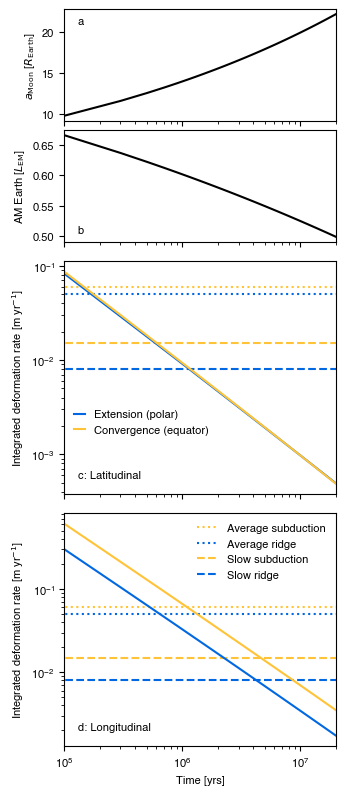

In [8]:
#plot the maximum and minimum deformation rates as a function of time
#This one I plot the integrated deformation rate in latitude/longitude
#the pretty version
#Now with orbital evolution


#initialise the figure
fig = plt.figure(figsize=(3.5,8.0))
gs = gridspec.GridSpec(3, 1,
                      width_ratios=[1],
                      height_ratios=[1,1,1])


gs000 = gridspec.GridSpecFromSubplotSpec(2, 1, 
                                        subplot_spec=gs[0],
                                        height_ratios=[1,1],
                                        )

ax=[[]]
ax[0].append(plt.subplot(gs[1]))
ax[0].append(plt.subplot(gs[2], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs000[0], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs000[1], sharex=ax[0][0]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)

col=cmaps.parula([0.15,0.85])



ddl_lat_dt_max=np.zeros(Nt)*np.nan
ddl_lat_dt_min=np.zeros(Nt)*np.nan

ddl_lon_dt_max=np.zeros(Nt)*np.nan
ddl_lon_dt_min=np.zeros(Nt)*np.nan


ind_max=Nt-1
for i in np.arange(ind_max):
    #longitudinal is easy. Accomodated around minor circle
    ddl_lon_dt_max[i]=np.amax(ddl_lon_dt[i,:])*const.year*2*np.pi
    ddl_lon_dt_min[i]=np.amin(ddl_lon_dt[i,:])*const.year*2*np.pi
    
    
    #latitudinal is harder. Need to integrate over surface
    temp=np.where(ddl_lat_dt[i,:]<0)[0][-1]
    
    #print(lat[0:temp])
    ddl_lat_dt_min[i]=2*integrate.trapz(ddl_lat_dt[i,0:temp]*const.year*np.pi/180.0,90.0-lat[0:temp])
    ddl_lat_dt_max[i]=integrate.trapz(ddl_lat_dt[i,(temp+1):]*const.year*np.pi/180.0,90.0-lat[(temp+1):])


ax[0][0].plot([0,t[ind_max]/const.year],[8E-3,8E-3],'--', color=col[0],linewidth=1.5) #slow mid ocean ridge
ax[0][0].plot([0,t[ind_max]/const.year],[15E-3,15E-3],'--', color=col[1],linewidth=1.5) #slow subduction
ax[0][0].plot([0,t[ind_max]/const.year],[50E-3,50E-3],':', color=col[0],linewidth=1.5) #average mid-ocean ridge
ax[0][0].plot([0,t[ind_max]/const.year],[60E-3,60E-3],':', color=col[1],linewidth=1.5) #avererage subduction

ax[0][1].plot([0,t[ind_max]/const.year],[60E-3,60E-3],':', color=col[1],linewidth=1.5, label='Average subduction') #avererage subduction
ax[0][1].plot([0,t[ind_max]/const.year],[50E-3,50E-3],':', color=col[0],linewidth=1.5, label='Average ridge') #average mid-ocean ridge
ax[0][1].plot([0,t[ind_max]/const.year],[15E-3,15E-3],'--', color=col[1],linewidth=1.5, label='Slow subduction') #slow subduction
ax[0][1].plot([0,t[ind_max]/const.year],[8E-3,8E-3],'--', color=col[0],linewidth=1.5, label='Slow ridge') #slow mid ocean ridge
    
ax[0][0].plot(t/const.year, np.absolute(ddl_lat_dt_max),'-', color=col[0],linewidth=1.5,label='Extension (polar)')
ax[0][0].plot(t/const.year, np.absolute(ddl_lat_dt_min),'-', color=col[1],linewidth=1.5,label='Convergence (equator)')

ax[0][1].plot(t/const.year, np.absolute(ddl_lon_dt_max),'-', color=col[0],linewidth=1.5)
ax[0][1].plot(t/const.year, np.absolute(ddl_lon_dt_min),'-', color=col[1],linewidth=1.5)

#plot orbital evolution
ax[0][2].plot(t/const.year, a/REarth, 'k-', linewidth=1.5)

ax[0][3].plot(t/const.year, L/LEM, 'k-', linewidth=1.5)

ax[0][0].set_xlim([1E5,2E7])


ax[0][0].set_yscale('log')
ax[0][1].set_yscale('log')


ax[0][0].set_xscale('log')
ax[0][1].set_xscale('log')
ax[0][2].set_xscale('log')
ax[0][3].set_xscale('log')

ax[0][0].set_ylabel('Integrated deformation rate [m yr$^{-1}$]')
ax[0][1].set_ylabel('Integrated deformation rate [m yr$^{-1}$]')

ax[0][2].set_ylabel(r"$a_{\rm Moon}$ [$R_{\rm Earth}$]")
ax[0][3].set_ylabel(r"AM Earth [$L_{\rm EM}$]")

ax[0][1].set_xlabel('Time [yrs]')

plt.setp( ax[0][0].get_xticklabels(), visible=False)
plt.setp( ax[0][2].get_xticklabels(), visible=False)
plt.setp( ax[0][3].get_xticklabels(), visible=False)


ax[0][0].legend(frameon=False, handlelength=1.0, loc='lower left',bbox_to_anchor=(0.0, 0.21))
ax[0][1].legend(frameon=False, handlelength=1.9, loc='upper right')#,bbox_to_anchor=(0.98, 1.36))

ax[0][2].text(0.05, 0.94, 'a', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.05, 0.06, 'b', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][3].transAxes, color='k')
  
ax[0][0].text(0.05, 0.06, 'c: Latitudinal', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.05, 0.06, 'd: Longitudinal', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][1].transAxes, color='k')
               

fig.tight_layout()
plt.savefig('Figure5.pdf')

